In [6]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import xgboost as xgb

import warnings
import pickle

In [7]:
!pip install xgboost

In [8]:
import pandas as pd

data = pd.read_csv(
    r"C:\Users\AKASH\Desktop\extract\Online-Payments-Fraud-Detection\data\PS_20174392719_1491204439457_log.csv"
)

data.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [10]:
data = data.drop(['nameOrig','nameDest'], axis=1, errors='ignore')

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['type'] = le.fit_transform(data['type'])

data = data.replace([np.inf, -np.inf], np.nan)
data = data.fillna(0)

In [11]:
x = data.drop('isFraud', axis=1)
y = data['isFraud']

In [12]:
data = data.drop(['nameOrig', 'nameDest'], axis=1, errors='ignore')

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['type'] = le.fit_transform(data['type'])

In [14]:
import numpy as np

data = data.replace([np.inf, -np.inf], np.nan)
data = data.fillna(0)

In [15]:
print(data.select_dtypes(include=['number']).max())

step              7.430000e+02
type              4.000000e+00
amount            9.244552e+07
oldbalanceOrg     5.958504e+07
newbalanceOrig    4.958504e+07
oldbalanceDest    3.560159e+08
newbalanceDest    3.561793e+08
isFraud           1.000000e+00
isFlaggedFraud    1.000000e+00
dtype: float64


In [16]:
num_cols = data.select_dtypes(include=['number']).columns

for col in num_cols:
    data[col] = data[col].clip(-1e12, 1e12)

In [17]:
x = data.drop('isFraud', axis=1)
y = data['isFraud']

In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rfc = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rfc.fit(x_train, y_train)

pred = rfc.predict(x_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9997202410327821


In [20]:
data.drop(['isFlaggedFraud'], axis = 1, inplace = True)

In [21]:
data

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,3,9839.64,170136.00,160296.36,0.00,0.00,0
1,1,3,1864.28,21249.00,19384.72,0.00,0.00,0
2,1,4,181.00,181.00,0.00,0.00,0.00,1
3,1,1,181.00,181.00,0.00,21182.00,0.00,1
4,1,3,11668.14,41554.00,29885.86,0.00,0.00,0
...,...,...,...,...,...,...,...,...
6362615,743,1,339682.13,339682.13,0.00,0.00,339682.13,1
6362616,743,4,6311409.28,6311409.28,0.00,0.00,0.00,1
6362617,743,1,6311409.28,6311409.28,0.00,68488.84,6379898.11,1
6362618,743,4,850002.52,850002.52,0.00,0.00,0.00,1


In [22]:
data.shape 

(6362620, 8)

In [23]:
plt.style.use('ggplot')
warnings.filterwarnings('ignore')

In [24]:
data.corr(numeric_only=True)

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
step,1.000000,0.006635,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578
type,0.006635,1.000000,0.088419,-0.339760,-0.352758,-0.104679,-0.059364,0.020833
amount,0.022373,0.088419,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.010058,-0.339760,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.010299,-0.352758,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.027665,-0.104679,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.025888,-0.059364,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.031578,0.020833,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


* <font color='DarkOrange'>step</font> : represents a unit of time where 1 step equals 1 hour
* <font color='Pink'>type</font> : type of online transaction
* <font color='Orange'>amount</font> : the amount of the transaction
* <font color='Yellow'>nameOrig</font> : customer starting the transaction
* <font color='Purple'>oldbalanceOrg</font> : balance before the transaction
* <font color='Green'>newbalanceOrig</font> : balance after the transaction
* <font color='Brown'>nameDest</font> : recipient of the transaction
* <font color='Tomato'>oldbalanceDest</font> : initial balance of recipient before the transaction
* <font color='DarkKhaki'>newbalanceDest</font> : the new balance of recipient after the transaction
* <font color='red'>isFraud</font> : fraud transaction

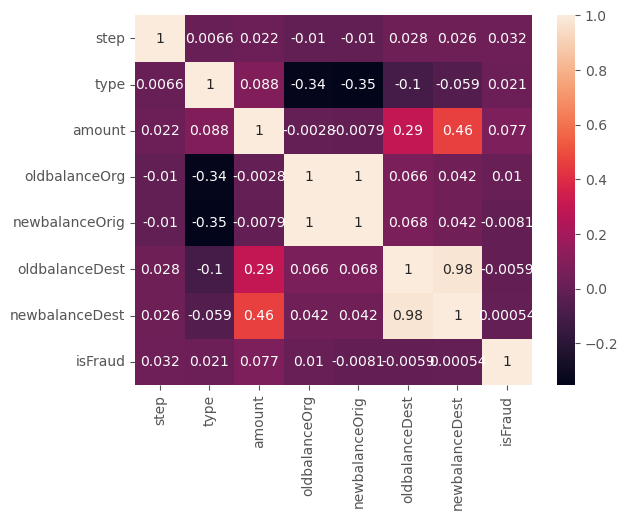

In [25]:
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

<Axes: xlabel='step', ylabel='Count'>

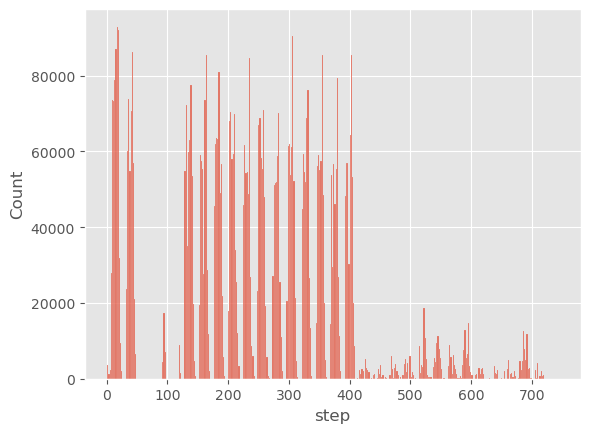

In [26]:
sns.histplot(data=data,x='step')

<Axes: xlabel='step'>

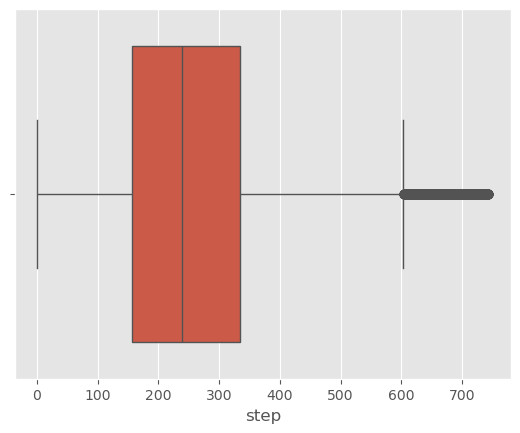

In [27]:
sns.boxplot(data=data,x='step')

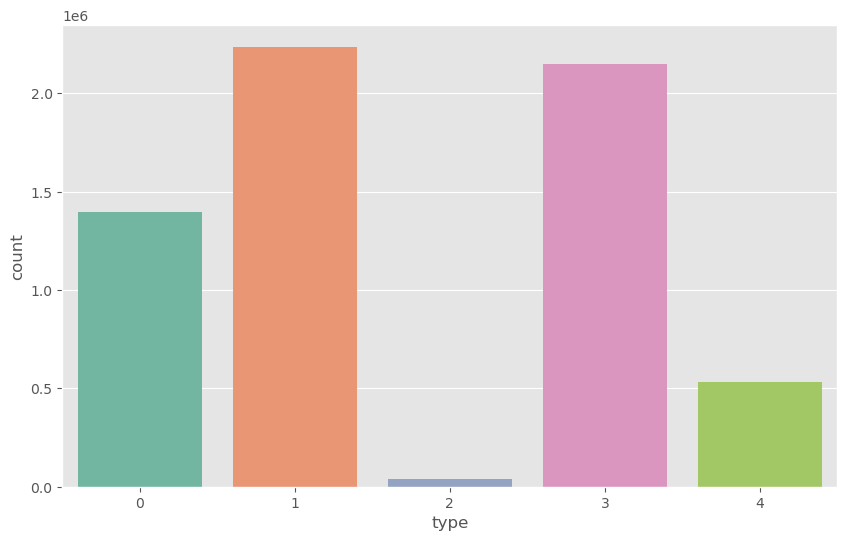

In [28]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=data,
    x='type',
    palette='Set2'
)

plt.show()

<Axes: xlabel='amount', ylabel='Count'>

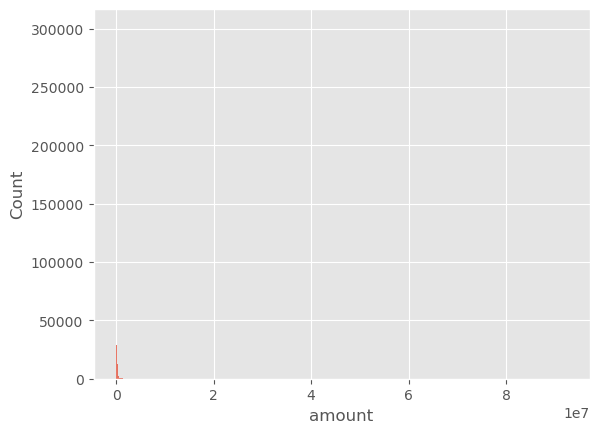

In [29]:
sns.histplot(data=data,x='amount')

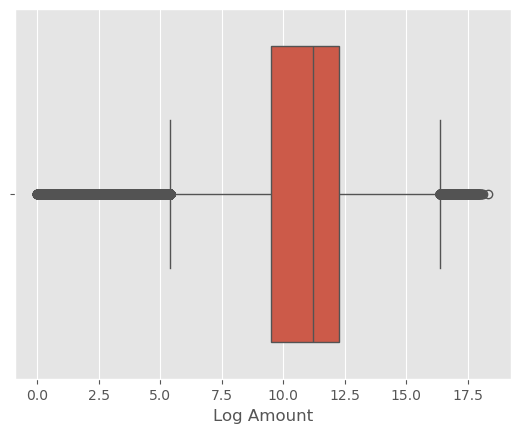

In [30]:
sns.boxplot(x=np.log1p(data['amount']))
plt.xlabel("Log Amount")
plt.show()

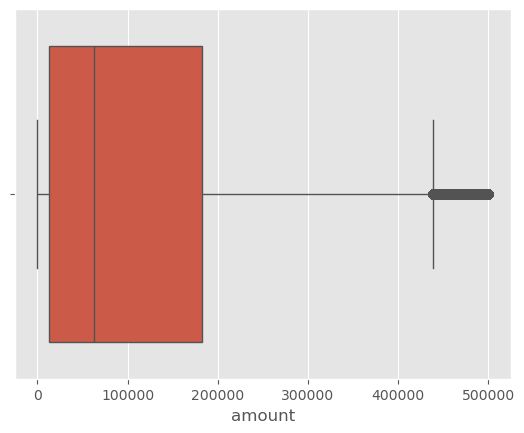

In [31]:
filtered = data[data['amount'] < 500000]
sns.boxplot(data=filtered, x='amount')
plt.show()

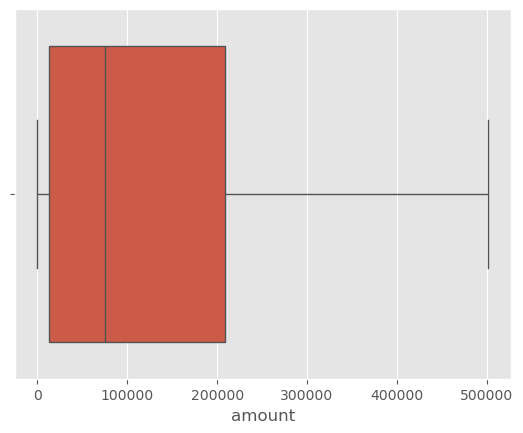

In [32]:
sns.boxplot(data=data, x='amount', showfliers=False)
plt.show()

<Axes: xlabel='oldbalanceOrg', ylabel='Count'>

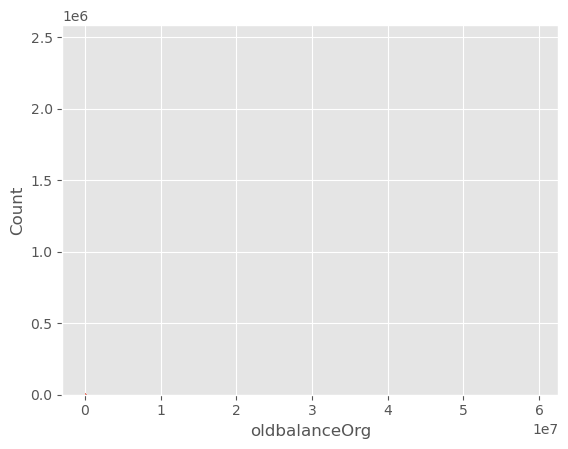

In [33]:
sns.histplot(data=data,x='oldbalanceOrg')

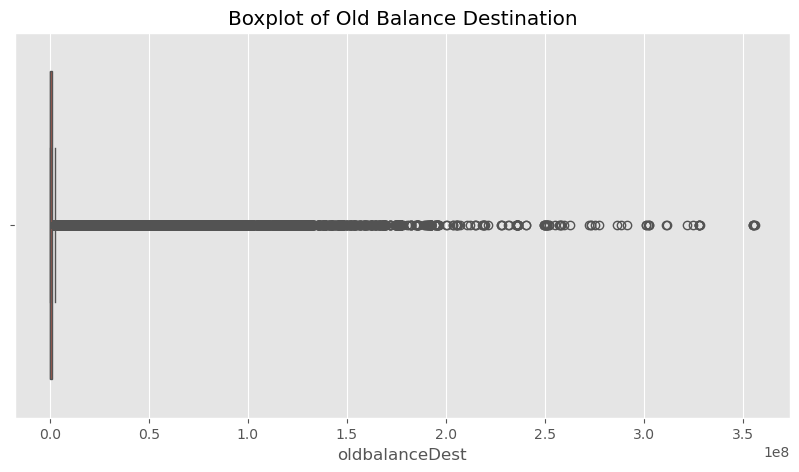

In [34]:
plt.figure(figsize=(10,5))
sns.boxplot(data=data, x='oldbalanceDest')
plt.title("Boxplot of Old Balance Destination")
plt.xlabel("oldbalanceDest")
plt.show()

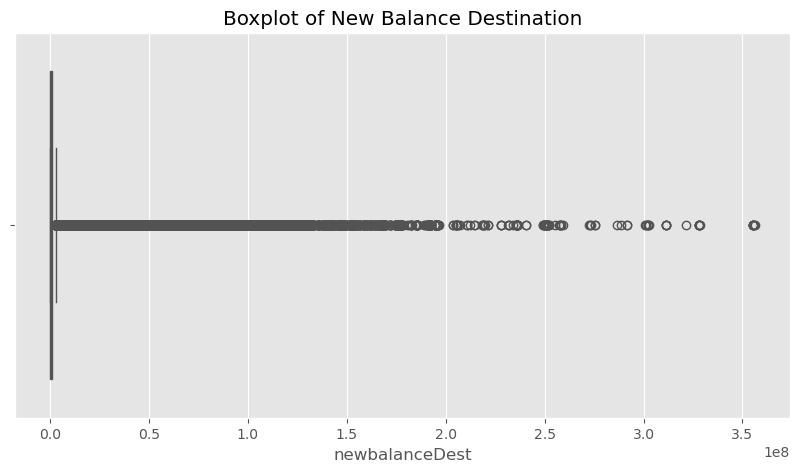

In [35]:
plt.figure(figsize=(10,5))
sns.boxplot(data=data, x='newbalanceDest')
plt.title("Boxplot of New Balance Destination")
plt.xlabel("newbalanceDest")
plt.show()

<Axes: xlabel='isFraud', ylabel='count'>

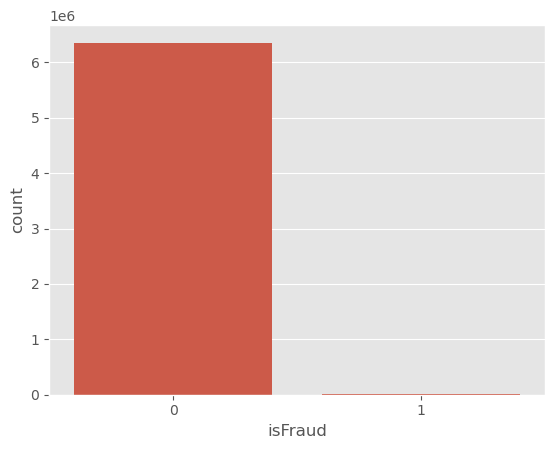

In [36]:
sns.countplot(data=data,x='isFraud')

In [37]:
data['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [38]:
data.loc[data['isFraud'] == 0, 'isFraud'] = 'is not Fraud'
data.loc[data['isFraud'] == 1, 'isFraud'] = 'is Fraud'

In [39]:
data

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,3,9839.64,170136.00,160296.36,0.00,0.00,is not Fraud
1,1,3,1864.28,21249.00,19384.72,0.00,0.00,is not Fraud
2,1,4,181.00,181.00,0.00,0.00,0.00,is Fraud
3,1,1,181.00,181.00,0.00,21182.00,0.00,is Fraud
4,1,3,11668.14,41554.00,29885.86,0.00,0.00,is not Fraud
...,...,...,...,...,...,...,...,...
6362615,743,1,339682.13,339682.13,0.00,0.00,339682.13,is Fraud
6362616,743,4,6311409.28,6311409.28,0.00,0.00,0.00,is Fraud
6362617,743,1,6311409.28,6311409.28,0.00,68488.84,6379898.11,is Fraud
6362618,743,4,850002.52,850002.52,0.00,0.00,0.00,is Fraud


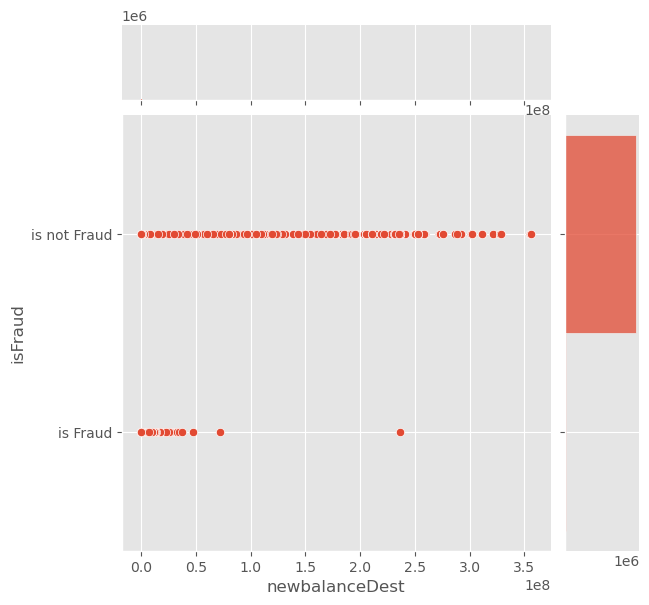

In [40]:
sns.jointplot(data=data,x='newbalanceDest',y='isFraud')

<Axes: xlabel='type', ylabel='count'>

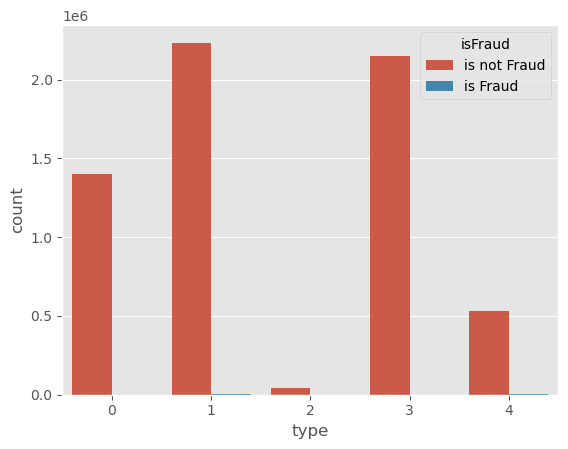

In [41]:
sns.countplot (data=data,x='type', hue='isFraud')

<Axes: xlabel='isFraud', ylabel='step'>

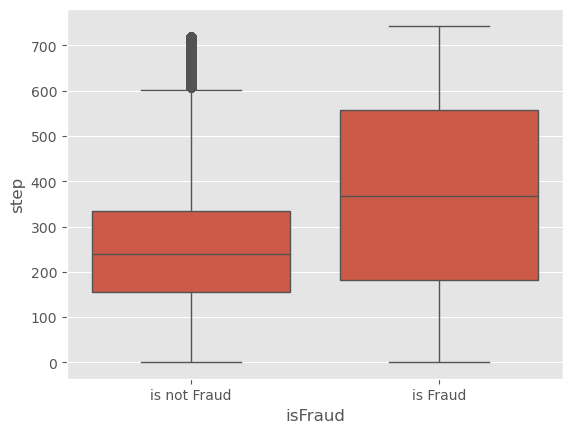

In [42]:
sns.boxplot(data=data,x='isFraud',y='step')

<Axes: xlabel='isFraud', ylabel='amount'>

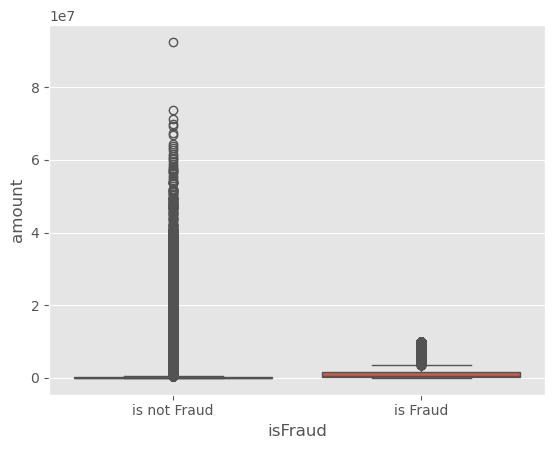

In [43]:
sns.boxplot(data=data,x='isFraud',y='amount')

<Axes: xlabel='isFraud', ylabel='oldbalanceOrg'>

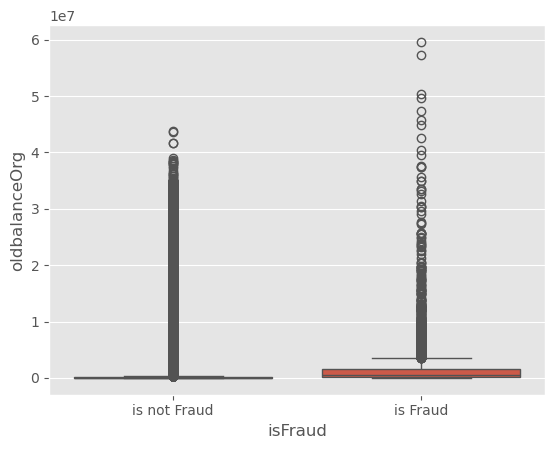

In [44]:
sns.boxplot(data=data,x='isFraud',y='oldbalanceOrg')

<Axes: xlabel='isFraud', ylabel='newbalanceOrig'>

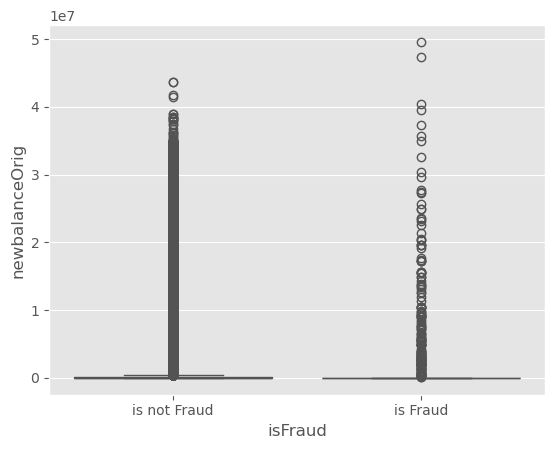

In [45]:
sns.boxplot(data=data,x='isFraud',y='newbalanceOrig')

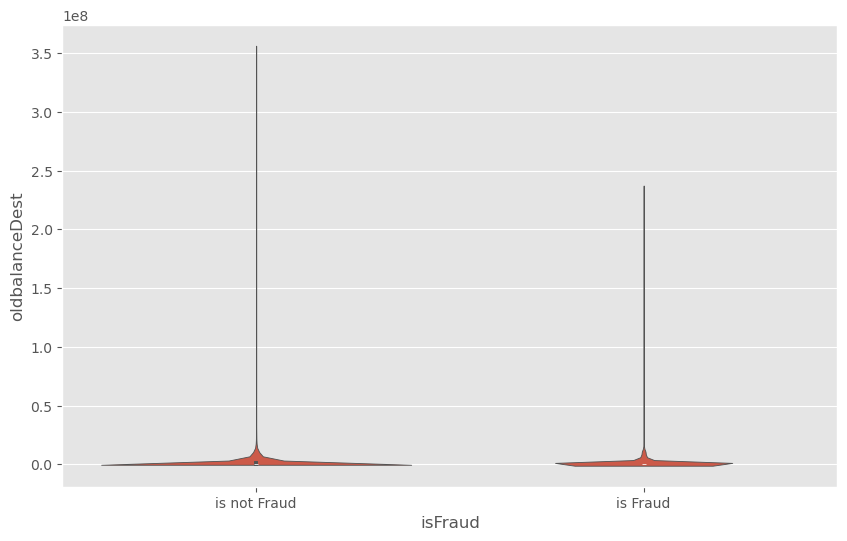

In [46]:
plt.figure(figsize=(10,6))
sns.violinplot(data=data, x='isFraud', y='oldbalanceDest')
plt.show()

<Axes: xlabel='isFraud', ylabel='newbalanceDest'>

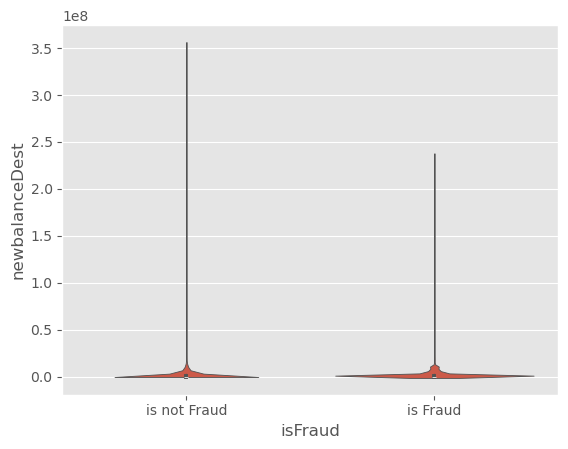

In [47]:
sns.violinplot(data=data,x='isFraud',y='newbalanceDest')

In [48]:
data.describe(include='all')

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6362620
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,is not Fraud
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6354407
mean,2.433972e+02,1.714150e+00,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,NaN
std,1.423320e+02,1.350117e+00,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,NaN
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
25%,1.560000e+02,1.000000e+00,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN
50%,2.390000e+02,1.000000e+00,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,NaN
75%,3.350000e+02,3.000000e+00,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,NaN


In [49]:
# Shape of csv data 
data.shape

(6362620, 8)

In [50]:
data.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,is not Fraud
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,is not Fraud
2,1,4,181.00,181.0,0.00,0.0,0.0,is Fraud
3,1,1,181.00,181.0,0.00,21182.0,0.0,is Fraud
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,is not Fraud


In [51]:
# Finding null values
data.isnull().sum()

step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            int64  
 2   amount          float64
 3   oldbalanceOrg   float64
 4   newbalanceOrig  float64
 5   oldbalanceDest  float64
 6   newbalanceDest  float64
 7   isFraud         object 
dtypes: float64(5), int64(2), object(1)
memory usage: 388.3+ MB


<Axes: ylabel='amount'>

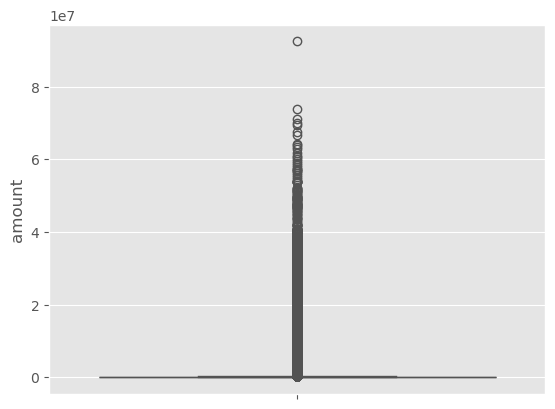

In [53]:
sns.boxplot(data['amount'])

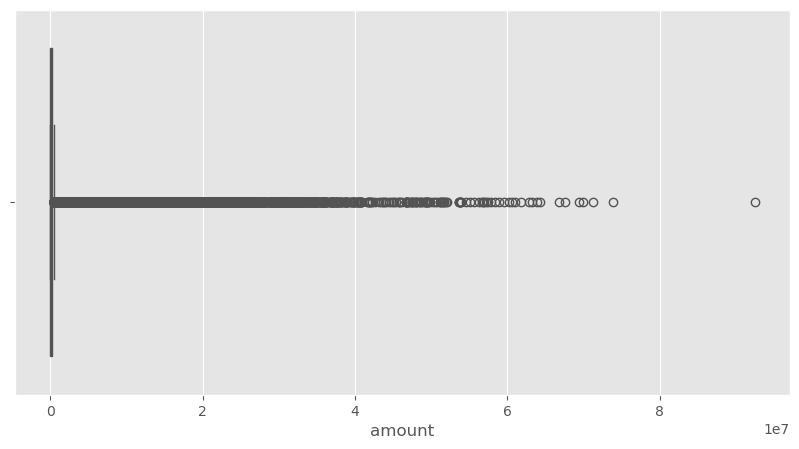

ModeResult(mode=array([10000000.]), count=array([3207]))
179861.90354913071
Q1: 13389.57
Q3: 208721.4775
IQR: 195331.9075
Upper Bound: 501719.33875
Lower Bound: -279608.29125
Skewed data Above Upper Bound: 338078
Skewed data Below Lower Bound: 0


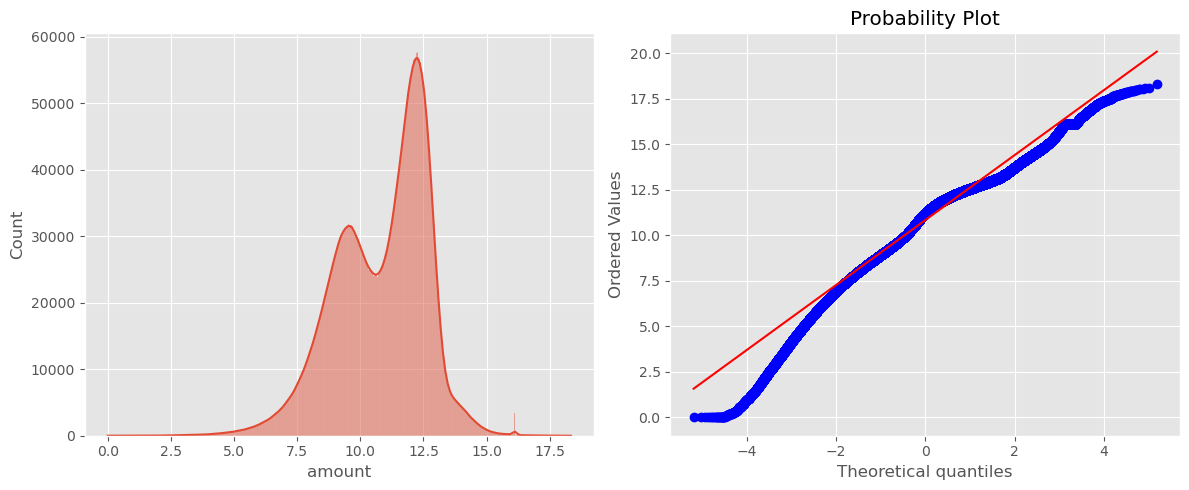

In [54]:
# Boxplot of amount
plt.figure(figsize=(10,5))
sns.boxplot(data=data, x='amount')
plt.show()

# Import stats
from scipy import stats

# Mode and Mean
print(stats.mode(data['amount'], keepdims=True))
print(np.mean(data['amount']))

# Quartiles and IQR
q1 = np.quantile(data['amount'], 0.25)
q3 = np.quantile(data['amount'], 0.75)

IQR = q3 - q1

upper_bound = q3 + (1.5 * IQR)
lower_bound = q1 - (1.5 * IQR)

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", IQR)
print("Upper Bound:", upper_bound)
print("Lower Bound:", lower_bound)

print("Skewed data Above Upper Bound:", len(data[data['amount'] > upper_bound]))
print("Skewed data Below Lower Bound:", len(data[data['amount'] < lower_bound]))

# Transformation Plot
def transformationPlot(feature):
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    sns.histplot(feature, kde=True)
    
    plt.subplot(1,2,2)
    stats.probplot(feature, plot=plt)
    
    plt.tight_layout()
    plt.show()

# Log Transformation
transformationPlot(np.log1p(data['amount']))

In [55]:
data['amount']=np.log(data['amount'])

In [56]:
from sklearn.preprocessing import LabelEncoder

la = LabelEncoder()

data['type'] = la.fit_transform(data['type'])

data['type'].value_counts()

type
1    2237500
3    2151495
0    1399284
4     532909
2      41432
Name: count, dtype: int64

In [57]:
x = data.drop('isFraud', axis=1) 
y = data['isFraud']
x

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
0,1,3,9.194174,170136.00,160296.36,0.00,0.00
1,1,3,7.530630,21249.00,19384.72,0.00,0.00
2,1,4,5.198497,181.00,0.00,0.00,0.00
3,1,1,5.198497,181.00,0.00,21182.00,0.00
4,1,3,9.364617,41554.00,29885.86,0.00,0.00
...,...,...,...,...,...,...,...
6362615,743,1,12.735766,339682.13,0.00,0.00,339682.13
6362616,743,4,15.657870,6311409.28,0.00,0.00,0.00
6362617,743,1,15.657870,6311409.28,0.00,68488.84,6379898.11
6362618,743,4,13.652995,850002.52,0.00,0.00,0.00


In [58]:
y

0          is not Fraud
1          is not Fraud
2              is Fraud
3              is Fraud
4          is not Fraud
               ...     
6362615        is Fraud
6362616        is Fraud
6362617        is Fraud
6362618        is Fraud
6362619        is Fraud
Name: isFraud, Length: 6362620, dtype: object

In [59]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5090096, 7)
(1272524, 7)
(5090096,)
(1272524,)


In [60]:
numeric_data = data.select_dtypes(include=['number'])

print(numeric_data.isnull().sum())
print(np.isinf(numeric_data).sum())

step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
dtype: int64
step               0
type               0
amount            16
oldbalanceOrg      0
newbalanceOrig     0
oldbalanceDest     0
newbalanceDest     0
dtype: int64


In [61]:
import numpy as np

# Replace bad values in amount
data['amount'] = data['amount'].replace([np.inf, -np.inf], np.nan)

# Fill missing with median
data['amount'] = data['amount'].fillna(data['amount'].median())

In [62]:
x = data.drop('isFraud', axis=1)
y = data['isFraud']

In [63]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [64]:
print(np.isfinite(x_train).all())

step              True
type              True
amount            True
oldbalanceOrg     True
newbalanceOrig    True
oldbalanceDest    True
newbalanceDest    True
dtype: bool


In [85]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rfc.fit(x_train, y_train)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [87]:
y_test_predict1 = rfc.predict(x_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_predict1))

In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_test_predict1))

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create model
dtc = DecisionTreeClassifier()

# Train model
dtc.fit(x_train, y_train)

# Predict
y_test_predict2 = dtc.predict(x_test)

# Accuracy
test_accuracy = accuracy_score(y_test, y_test_predict2)
print("Test Accuracy:", test_accuracy)

In [ ]:
print(np.isfinite(x_train).all())

In [ ]:
y_train_predict2 = dtc.predict(x_train)

train_accuracy = accuracy_score(y_train, y_train_predict2)

print("Train Accuracy:", train_accuracy)

In [ ]:
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

In [ ]:
pd.crosstab(y_test,y_test_predict2)

In [ ]:
print(classification_report(y_test,y_test_predict2))

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score

# Create model
etc = ExtraTreesClassifier()

# Train model
etc.fit(x_train, y_train)

# Predict on test data
y_test_predict3 = etc.predict(x_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_test_predict3)

print("Test Accuracy:", test_accuracy)

In [ ]:
y_train_predict3 = etc.predict(x_train)

train_accuracy = accuracy_score(y_train, y_train_predict3)

print("Train Accuracy:", train_accuracy)

In [ ]:
pd.crosstab(y_test,y_test_predict3)

In [ ]:
print(classification_report(y_test,y_test_predict3))

In [ ]:
data.columns

In [ ]:
from sklearn.preprocessing import LabelEncoder

la = LabelEncoder()

y_train1 = la.fit_transform(y_train)

y_test1 = la.transform(y_test)

In [88]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

xgb1 = xgb.XGBClassifier()

xgb1.fit(x_train, y_train1)

y_test_predict5 = xgb1.predict(x_test)

test_accuracy = accuracy_score(y_test1, y_test_predict5)

print("XGBoost Test Accuracy:", test_accuracy)

XGBoost Test Accuracy: 0.9995795757093776


In [89]:
# Train accuracy
y_train_predict5 = xgb1.predict(x_train)
train_accuracy_xgb = accuracy_score(y_train1, y_train_predict5)

In [90]:
pd.crosstab(y_test1,y_test_predict5)

col_0,0,1
row_0,,
0,1262,358
1,177,1270727


In [91]:
print("XGBoost Train Accuracy:", train_accuracy_xgb)

XGBoost Train Accuracy: 0.9995950960453398


In [92]:
# Evaluation
print(confusion_matrix(y_test1, y_test_predict5))
print(classification_report(y_test1, y_test_predict5))

[[   1262     358]
 [    177 1270727]]
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1620
           1       1.00      1.00      1.00   1270904

    accuracy                           1.00   1272524
   macro avg       0.94      0.89      0.91   1272524
weighted avg       1.00      1.00      1.00   1272524



In [93]:
best_model = xgb1

import pickle
pickle.dump(best_model, open('best_model.pkl', 'wb'))

In [94]:
import xgboost as xgb

In [95]:
xgb1 = xgb.XGBClassifier()

xgb1.fit(x_train, y_train1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [96]:
xgb1.save_model("fraud_model.json")

In [97]:
import os
print(os.listdir())

['.ipynb_checkpoints', '.venv', 'app.py', 'best_model.pkl', 'data', 'fraud_model.json', 'JupyterLab.pdf', 'main.ipynb', 'model.pkl', 'README.md', 'static', 'templates']


In [98]:
import xgboost as xgb

model = xgb.XGBClassifier()
model.load_model("fraud_model.json")

In [99]:
print(x.columns)

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest'],
      dtype='object')


In [100]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

In [106]:
import pandas as pd

data = pd.read_csv(
    r"C:\Users\AKASH\Desktop\extract\Online-Payments-Fraud-Detection\data\PS_20174392719_1491204439457_log.csv"
)

data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [102]:
data.shape
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            int64  
 2   amount          float64
 3   oldbalanceOrg   float64
 4   newbalanceOrig  float64
 5   oldbalanceDest  float64
 6   newbalanceDest  float64
 7   isFraud         object 
dtypes: float64(5), int64(2), object(1)
memory usage: 388.3+ MB


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.714150e+00,1.084067e+01,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06
std,1.423320e+02,1.350117e+00,1.815242e+00,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06
min,1.000000e+00,0.000000e+00,-4.605170e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.000000e+00,9.502248e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,1.000000e+00,1.122355e+01,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05
75%,3.350000e+02,3.000000e+00,1.224876e+01,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06
max,7.430000e+02,4.000000e+00,1.834213e+01,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08


In [103]:
data = data.drop(['nameOrig', 'nameDest'], axis=1, errors='ignore')

In [104]:
# Replace inf values
data = data.replace([np.inf, -np.inf], np.nan)

# Fill missing values
data = data.fillna(0)

In [105]:
# Replace inf values
data = data.replace([np.inf, -np.inf], np.nan)

# Fill missing values
data = data.fillna(0)

In [107]:
print(data.isnull().sum())
print(np.isinf(data.select_dtypes(include=['number'])).sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [108]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['type'] = le.fit_transform(data['type'])

In [109]:
# Apply log transformation to amount
data['amount'] = np.log(data['amount'] + 1)

In [110]:
# Clip extreme values
num_cols = data.select_dtypes(include=['number']).columns

for col in num_cols:
    data[col] = data[col].clip(-1e12, 1e12)

In [111]:
X = data.drop('isFraud', axis=1)
y = data['isFraud']

In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [113]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=10   # 🔥 important
)

In [135]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [115]:
print(data.columns)

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')


In [116]:
data = data.drop(['nameOrig', 'nameDest'], axis=1, errors='ignore')

In [117]:
print(data.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [118]:
X = data.drop('isFraud', axis=1)
y = data['isFraud']

In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [120]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [121]:
print(X_train.dtypes)

step                int64
type                int64
amount            float64
oldbalanceOrg     float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
isFlaggedFraud      int64
dtype: object


In [122]:
data = data.drop('isFlaggedFraud', axis=1)

In [123]:
print(data.columns)

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud'],
      dtype='object')


In [124]:
X = data.drop('isFraud', axis=1)
y = data['isFraud']

In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [126]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [127]:
print(X_train.shape, y_train.shape)

(10167006, 7) (10167006,)


In [128]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [129]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1251234   19670]
 [      4    1616]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270904
           1       0.08      1.00      0.14      1620

    accuracy                           0.98   1272524
   macro avg       0.54      0.99      0.57   1272524
weighted avg       1.00      0.98      0.99   1272524



In [130]:
sample = X_test.iloc[0:1]

print(model.predict(sample))
print(model.predict_proba(sample))

[0]
[[9.9975109e-01 2.4889034e-04]]


In [131]:
model.save_model("fraud_model.json")

In [132]:
import pickle

pickle.dump(le, open("type_encoder.pkl", "wb"))

In [133]:
test_input = [[
    10,     # step
    3,      # PAYMENT
    np.log(1000 + 1),
    5000,
    4000,
    2000,
    3000
]]

import numpy as np
test_input = np.array(test_input)

print(model.predict(test_input))
print(model.predict_proba(test_input))

[0]
[[9.991336e-01 8.664077e-04]]


In [134]:
print(X_train.dtypes)

step                int64
type                int64
amount            float64
oldbalanceOrg     float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
dtype: object


In [136]:
print(y_train.value_counts())

isFraud
0    5083503
1    5083503
Name: count, dtype: int64


In [137]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, ...)

In [138]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1262928    7976]
 [      6    1614]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270904
           1       0.17      1.00      0.29      1620

    accuracy                           0.99   1272524
   macro avg       0.58      1.00      0.64   1272524
weighted avg       1.00      0.99      1.00   1272524



In [139]:
sample = X_test.iloc[0:1]

print(model.predict(sample))
print(model.predict_proba(sample))

[0]
[[9.9991614e-01 8.3874213e-05]]


In [140]:
model.save_model("fraud_model.json")